# Reto 02 — Comparación de algoritmos para Multi-Armed Bandits

**Integrantes:** Katherine Bustamante 

**Correos:** sandra.bustamante97@eia.edu.co 

**Fecha:** 2026-08-02

## Objetivo

Comprender, implementar y comparar diferentes estrategias de exploración-explotación en el problema Multi-Armed Bandit, analizando su comportamiento, ventajas, limitaciones y desempeño en distintos escenarios.

## 1. Preparación del entorno

In [8]:
from __future__ import annotations

from pathlib import Path
import sys

# Agregar la carpeta challenge_02_bandit_algorithms al path
sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from starter_code import (
    GaussianBandit,
    cumulative_average,
    cumulative_regret,
    optimal_action_rate,
)

SEED = 2026
HORIZON = 1_000
N_RUNS = 100
MEANS = np.array([1.0, 2.0, 1.5])
STDS = np.array([0.5, 0.5, 1.5])
ARM_NAMES = np.array(["A1", "A2", "A3"])

## 2. Verificación del bandit

Crea el entorno, muestra sus propiedades y explica por qué A2 es el brazo óptimo.

In [9]:
bandit = GaussianBandit(MEANS, STDS, seed=SEED)
print(f"Número de brazos: {bandit.n_arms}")
print(f"Brazo óptimo: {ARM_NAMES[bandit.optimal_arm]}")
print(f"Media óptima: {bandit.optimal_mean}")

Número de brazos: 3
Brazo óptimo: A2
Media óptima: 2.0


## 3. Funciones auxiliares

Implementa actualización incremental y selección aleatoria entre empates.

In [10]:
def random_argmax(values: np.ndarray, rng: np.random.Generator) -> int:
    # TODO: seleccionar aleatoriamente entre todos los índices máximos.
    max_value = np.max(values)
    mejores = np.flatnonzero(values == max_value)
    return rng.choice(mejores)


def incremental_update(estimate: float, reward: float, count: int) -> float:
    # TODO: aplicar la actualización de media incremental.
    return estimate + (reward - estimate) / count


## 4. ε-greedy

In [11]:
def run_epsilon_greedy(
    *,
    epsilon: float,
    initial_value: float,
    horizon: int,
    seed: int,
) -> pd.DataFrame:

    if not 0 <= epsilon <= 1:
        raise ValueError("epsilon debe estar entre 0 y 1.")

    if horizon <= 0:
        raise ValueError("horizon debe ser positivo.")

    if not np.isfinite(initial_value):
        raise ValueError("initial_value debe ser finito.")

    bandit = GaussianBandit(
        MEANS,
        STDS,
        seed=seed
    )

    rng = np.random.default_rng(seed)

    Q = np.full(
        bandit.n_arms,
        initial_value,
        dtype=float
    )

    N = np.zeros(
        bandit.n_arms,
        dtype=int
    )

    timesteps = []
    actions = []
    rewards = []
    q_history = []

    for t in range(horizon):

        # Selección ε-greedy
        if rng.random() < epsilon:
            arm = rng.integers(bandit.n_arms)
        else:
            arm = random_argmax(Q, rng)

        # Recompensa
        reward = bandit.pull(arm)

        # Actualización
        N[arm] += 1

        Q[arm] = incremental_update(
            Q[arm],
            reward,
            N[arm]
        )

        # Guardar resultados
        timesteps.append(t)
        actions.append(arm+1)
        rewards.append(reward)
        q_history.append(Q.copy())

    q_history = np.array(q_history)

    return pd.DataFrame({
        "step": timesteps,
        "action": actions,
        "reward": rewards,
        "q_a1": q_history[:, 0],
        "q_a2": q_history[:, 1],
        "q_a3": q_history[:, 2],
    })

In [12]:
e_greedy_resultados =run_epsilon_greedy(
    epsilon=0.1,
    initial_value=0.0,
    horizon=10,
    seed=SEED
)

e_greedy_resultados.head(10)



,step,action,reward,q_a1,q_a2,q_a3
0,0,1,0.603439,0.603439,0.0,0.0
1,1,1,1.120286,0.861862,0.0,0.0
2,2,1,0.051837,0.591854,0.0,0.0
3,3,1,1.697886,0.868362,0.0,0.0
4,4,1,1.319147,0.958519,0.0,0.0
5,5,1,0.853976,0.941095,0.0,0.0
6,6,1,0.844025,0.927228,0.0,0.0
7,7,1,1.151918,0.955314,0.0,0.0
8,8,1,0.866170,0.945409,0.0,0.0
9,9,1,0.887046,0.939573,0.0,0.0


## 5. ε-greedy con inicio optimista

Reutiliza la implementación anterior con ε = 0 y Q0 = 5. Explica el mecanismo de exploración.

In [13]:
e_greedy_opt_resultados =run_epsilon_greedy(
    epsilon=0,
    initial_value=5,
    horizon=10,
    seed=SEED
)

e_greedy_opt_resultados.head(10)



,step,action,reward,q_a1,q_a2,q_a3
0,0,1,0.603439,0.603439,5.000000,5.000000
1,1,3,1.860857,0.603439,5.000000,1.860857
2,2,2,1.051837,0.603439,1.051837,1.860857
3,3,3,3.593658,0.603439,1.051837,2.727257
4,4,3,2.457442,0.603439,1.051837,2.637319
5,5,3,1.061929,0.603439,1.051837,2.243471
6,6,3,1.032076,0.603439,1.051837,2.001192
7,7,3,1.955753,0.603439,1.051837,1.993619
8,8,3,1.098510,0.603439,1.051837,1.865746
9,9,3,1.161137,0.603439,1.051837,1.777670


## 6. UCB

TODO: seleccionar cada brazo una vez y aplicar la regla UCB.

In [14]:
def run_ucb(
    *,
    c: float,
    horizon: int,
    seed: int
) -> pd.DataFrame:

    if c < 0:
        raise ValueError("c debe ser no negativo.")

    if horizon <= 0:
        raise ValueError("horizon debe ser positivo.")

    bandit = GaussianBandit(
        MEANS,
        STDS,
        seed=seed
    )

    rng = np.random.default_rng(seed)

    Q = np.zeros(
        bandit.n_arms,
        dtype=float
    )

    N = np.zeros(
        bandit.n_arms,
        dtype=int
    )

    timesteps = []
    actions = []
    rewards = []
    q_history = []

    for t in range(horizon):

        # Primero seleccionar cada brazo una vez
        untested = np.flatnonzero(N == 0)

        if untested.size > 0:

            arm = rng.choice(untested)

        else:

            total_pulls = np.sum(N)

            ucb_values = (
                Q
                + c * np.sqrt(
                    np.log(total_pulls) / N
                )
            )

            arm = random_argmax(
                ucb_values,
                rng
            )

        # Recompensa
        reward = bandit.pull(arm)

        # Actualización
        N[arm] += 1

        Q[arm] = incremental_update(
            Q[arm],
            reward,
            N[arm]
        )

        # Guardar resultados
        timesteps.append(t)
        actions.append(arm+1)
        rewards.append(reward)
        q_history.append(Q.copy())

    q_history = np.array(q_history)

    return pd.DataFrame({
        "step": timesteps,
        "action": actions,
        "reward": rewards,
        "q_a1": q_history[:, 0],
        "q_a2": q_history[:, 1],
        "q_a3": q_history[:, 2],
    })

In [15]:
resultado_ucb = run_ucb(
    c=2.0,
    horizon=3,
    seed=SEED
)

resultado_ucb.head(10)

,step,action,reward,q_a1,q_a2,q_a3
0,0,3,0.310316,0.000000,0.000000,0.310316
1,1,1,1.120286,1.120286,0.000000,0.310316
2,2,2,1.051837,1.120286,1.051837,0.310316


In [16]:
resultado_ucb["action"].value_counts().sort_index()

action
1    1
2    1
3    1
Name: count, dtype: int64

## 7. Softmax

TODO: calcular probabilidades estables y muestrear una acción.

In [17]:
def run_softmax(
    *,
    temperature: float,
    horizon: int,
    seed: int
) -> pd.DataFrame:

    if temperature <= 0:
        raise ValueError(
            "temperature debe ser positiva."
        )

    if horizon <= 0:
        raise ValueError(
            "horizon debe ser positivo."
        )

    bandit = GaussianBandit(
        MEANS,
        STDS,
        seed=seed
    )

    rng = np.random.default_rng(seed)

    Q = np.zeros(
        bandit.n_arms,
        dtype=float
    )

    N = np.zeros(
        bandit.n_arms,
        dtype=int
    )

    timesteps = []
    actions = []
    rewards = []
    q_history = []

    for t in range(horizon):

        # Softmax estable
        logits = (
            Q - np.max(Q)
        ) / temperature

        exp_values = np.exp(logits)

        probabilities = (
            exp_values / np.sum(exp_values)
        )

        arm = rng.choice(
            bandit.n_arms,
            p=probabilities
        )

        # Recompensa
        reward = bandit.pull(arm)

        # Actualización
        N[arm] += 1

        Q[arm] = incremental_update(
            Q[arm],
            reward,
            N[arm]
        )

        # Guardar resultados
        timesteps.append(t)
        actions.append(arm+1)
        rewards.append(reward)
        q_history.append(Q.copy())

    q_history = np.array(q_history)

    return pd.DataFrame({
        "step": timesteps,
        "action": actions,
        "reward": rewards,
        "q_a1": q_history[:, 0],
        "q_a2": q_history[:, 1],
        "q_a3": q_history[:, 2],
    })

In [18]:
resultado_softmax = run_softmax(
    temperature=0.2,
    horizon=10,
    seed=SEED
)

resultado_softmax.head()

,step,action,reward,q_a1,q_a2,q_a3
0,0,1,0.603439,0.603439,0.0,0.0
1,1,1,1.120286,0.861862,0.0,0.0
2,2,1,0.051837,0.591854,0.0,0.0
3,3,1,1.697886,0.868362,0.0,0.0
4,4,1,1.319147,0.958519,0.0,0.0


In [19]:
resultado_softmax["action"].value_counts().sort_index()

action
1    10
Name: count, dtype: int64

## 8. Pruebas pequeñas

Verifica longitud, acciones válidas, conteos y reproducibilidad antes del experimento completo.

In [20]:
# TODO: agregar aserciones para cada implementación.

# -----------------------------
# Pruebas pequeñas
# -----------------------------

TEST_HORIZON = 20
TEST_SEED = 2026

# ==========================================
# 1. ε-greedy
# ==========================================

eg_1 = run_epsilon_greedy(
    epsilon=0.1,
    initial_value=0.0,
    horizon=TEST_HORIZON,
    seed=TEST_SEED
)

eg_2 = run_epsilon_greedy(
    epsilon=0.1,
    initial_value=0.0,
    horizon=TEST_HORIZON,
    seed=TEST_SEED
)

# Longitud
assert len(eg_1) == TEST_HORIZON

# Acciones válidas
assert eg_1["action"].isin(range(1, len(MEANS) + 1)).all()

# Reproducibilidad
assert eg_1.equals(eg_2)


# ==========================================
# 2. Inicio optimista
# ==========================================

optimista = run_epsilon_greedy(
    epsilon=0.0,
    initial_value=5.0,
    horizon=TEST_HORIZON,
    seed=TEST_SEED
)

# Longitud
assert len(optimista) == TEST_HORIZON

# Acciones válidas
assert optimista["action"].isin(range(1, len(MEANS) + 1)).all()


# ==========================================
# 3. UCB
# ==========================================

ucb_1 = run_ucb(
    c=2.0,
    horizon=TEST_HORIZON,
    seed=TEST_SEED
)

ucb_2 = run_ucb(
    c=2.0,
    horizon=TEST_HORIZON,
    seed=TEST_SEED
)

# Longitud
assert len(ucb_1) == TEST_HORIZON

# Acciones válidas
assert set(ucb_1["action"].iloc[:len(MEANS)]) == set(range(1, len(MEANS) + 1))

# Reproducibilidad
assert ucb_1.equals(ucb_2)

# UCB debe seleccionar cada brazo al menos una vez
assert set(ucb_1["action"].iloc[:len(MEANS)]) == set(range(1, len(MEANS) + 1))


# ==========================================
# 4. Softmax
# ==========================================

softmax_1 = run_softmax(
    temperature=0.5,
    horizon=TEST_HORIZON,
    seed=TEST_SEED
)

softmax_2 = run_softmax(
    temperature=0.5,
    horizon=TEST_HORIZON,
    seed=TEST_SEED
)

# Longitud
assert len(softmax_1) == TEST_HORIZON

# Acciones válidas
assert softmax_1["action"].isin(range(1, len(MEANS) + 1)).all()

# Reproducibilidad
assert softmax_1.equals(softmax_2)


print("Todas las pruebas pasaron correctamente.")

Todas las pruebas pasaron correctamente.


## 9. Comparación principal

Ejecuta 100 corridas de 1.000 pasos por algoritmo. Agrega las curvas y reporta su variabilidad.

In [21]:
# -----------------------------
# Almacenar resultados
# -----------------------------

resultados_epsilon = []
resultados_optimista = []
resultados_ucb = []
resultados_softmax = []

# -----------------------------
# Ejecutar N_RUNS corridas
# -----------------------------

for run in range(N_RUNS):

    seed = SEED + run

    # ==========================================
    # 1. ε-greedy
    # ==========================================

    resultado = run_epsilon_greedy(
        epsilon=0.1,
        initial_value=0.0,
        horizon=HORIZON,
        seed=seed
    )

    resultados_epsilon.append(resultado)

    # ==========================================
    # 2. ε-greedy + inicio optimista
    # ==========================================

    resultado = run_epsilon_greedy(
        epsilon=0.0,
        initial_value=5.0,
        horizon=HORIZON,
        seed=seed
    )

    resultados_optimista.append(resultado)

    # ==========================================
    # 3. UCB
    # ==========================================

    resultado = run_ucb(
        c=2.0,
        horizon=HORIZON,
        seed=seed
    )

    resultados_ucb.append(resultado)

    # ==========================================
    # 4. Softmax
    # ==========================================

    resultado = run_softmax(
        temperature=0.5,
        horizon=HORIZON,
        seed=seed
    )

    resultados_softmax.append(resultado)

# -----------------------------
# Comprobación
# -----------------------------

print("Corridas ε-greedy:", len(resultados_epsilon))
print("Corridas optimistas:", len(resultados_optimista))
print("Corridas UCB:", len(resultados_ucb))
print("Corridas Softmax:", len(resultados_softmax))

print("\nFilas por corrida:")
print(len(resultados_epsilon[0]))

Corridas ε-greedy: 100
Corridas optimistas: 100
Corridas UCB: 100
Corridas Softmax: 100

Filas por corrida:
1000


## 10. Tabla resumen y visualizaciones

Incluye recompensa, acción óptima, regret y distribución final de acciones.

In [22]:
# ============================================================
# 10. Análisis de resultados
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Agrupar resultados
# ------------------------------------------------------------

resultados_base = {
    "ε-greedy": resultados_epsilon,
    "ε-optimista": resultados_optimista,
    "UCB": resultados_ucb,
    "Softmax": resultados_softmax,
}


# ------------------------------------------------------------
# Analizar cada algoritmo
# ------------------------------------------------------------

def analizar_resultados(runs):
    """
    Calcula métricas por timestep para todas las corridas.
    """

    rewards = np.array([
        run["reward"].to_numpy()
        for run in runs
    ])

    actions = np.array([
        run["action"].to_numpy()-1
        for run in runs
    ])

    n_runs, horizon = rewards.shape

    brazo_optimo = int(np.argmax(MEANS))

    # ========================================================
    # 1. Recompensa acumulada
    # ========================================================

    recompensa_acumulada = np.cumsum(
        rewards,
        axis=1
    )

    recompensa_acumulada_media = np.mean(
        recompensa_acumulada,
        axis=0
    )

    recompensa_acumulada_std = np.std(
        recompensa_acumulada,
        axis=0
    )

    # ========================================================
    # 2. Recompensa media acumulada
    # ========================================================

    pasos = np.arange(1, horizon + 1)

    recompensa_media_acumulada = (
        recompensa_acumulada / pasos
    )

    recompensa_media_acumulada_media = np.mean(
        recompensa_media_acumulada,
        axis=0
    )

    recompensa_media_acumulada_std = np.std(
        recompensa_media_acumulada,
        axis=0
    )

    # ========================================================
    # 3. Selección acumulada del brazo óptimo
    # ========================================================

    seleccion_optima = (
        actions == brazo_optimo
    )

    seleccion_optima_acumulada = (
        np.cumsum(seleccion_optima, axis=1)
        / pasos
        * 100
    )

    seleccion_optima_media = np.mean(
        seleccion_optima_acumulada,
        axis=0
    )

    seleccion_optima_std = np.std(
        seleccion_optima_acumulada,
        axis=0
    )

    # ========================================================
    # 4. Pseudo-regret acumulado
    # ========================================================

    regret_por_paso = (
        MEANS[brazo_optimo]
        - MEANS[actions]
    )

    regret_acumulado = np.cumsum(
        regret_por_paso,
        axis=1
    )

    regret_acumulado_media = np.mean(
        regret_acumulado,
        axis=0
    )

    regret_acumulado_std = np.std(
        regret_acumulado,
        axis=0
    )

    # ========================================================
    # 5. Distribución final de acciones
    # ========================================================

    conteos = np.zeros(
        len(MEANS)
    )

    for run_actions in actions:

        valores, counts = np.unique(
            run_actions,
            return_counts=True
        )

        conteos[valores] += counts

    distribucion_final = (
        conteos
        / (n_runs * horizon)
        * 100
    )

    return {
        "recompensa_acumulada_media":
            recompensa_acumulada_media,

        "recompensa_acumulada_std":
            recompensa_acumulada_std,

        "recompensa_media_acumulada_media":
            recompensa_media_acumulada_media,

        "recompensa_media_acumulada_std":
            recompensa_media_acumulada_std,

        "seleccion_optima_media":
            seleccion_optima_media,

        "seleccion_optima_std":
            seleccion_optima_std,

        "regret_media":
            regret_acumulado_media,

        "regret_std":
            regret_acumulado_std,

        "distribucion_final":
            distribucion_final,
    }


# ------------------------------------------------------------
# Analizar los cuatro algoritmos
# ------------------------------------------------------------

analisis_base = {
    nombre: analizar_resultados(runs)
    for nombre, runs in resultados_base.items()
}

### Tabla resumen final

In [23]:
colores = {
    "ε-greedy": "#5F9EA0",      # teal pastel oscuro
    "ε-optimista": "#E0A458",   # naranja pastel oscuro
    "UCB": "#8E7DBE",            # violeta pastel oscuro
    "Softmax": "#D77A8A",        # rosa pastel oscuro
}

In [24]:
# ============================================================
# Tabla resumen final
# ============================================================

filas = []

for nombre, datos in analisis_base.items():

    filas.append({
        "Algoritmo": nombre,

        "Recompensa acumulada media":
            datos["recompensa_acumulada_media"][-1],

        "Desv. estándar recompensa":
            datos["recompensa_acumulada_std"][-1],

        "Recompensa media acumulada":
            datos["recompensa_media_acumulada_media"][-1],

        "Acción óptima (%)":
            datos["seleccion_optima_media"][-1],

        "Desv. estándar acción óptima":
            datos["seleccion_optima_std"][-1],

        "Pseudo-regret acumulado":
            datos["regret_media"][-1],

        "Desv. estándar regret":
            datos["regret_std"][-1],
    })

tabla_resumen = pd.DataFrame(filas)

display(tabla_resumen)

,Algoritmo,Recompensa acumulada media,Desv. estándar recompensa,Recompensa media acumulada,Acción óptima (%),Desv. estándar acción óptima,Pseudo-regret acumulado,Desv. estándar regret
0,ε-greedy,1933.679470,29.966971,1.933679,90.597,4.264937,66.90,24.308023
1,ε-optimista,1975.359033,93.212001,1.975359,95.199,19.566407,24.77,98.029216
2,UCB,1950.957228,20.334436,1.950957,92.484,3.340740,47.93,16.895712
3,Softmax,1800.582825,42.002428,1.800583,69.584,8.069309,199.41,39.108208


### Gráfica recompensa media acumulada

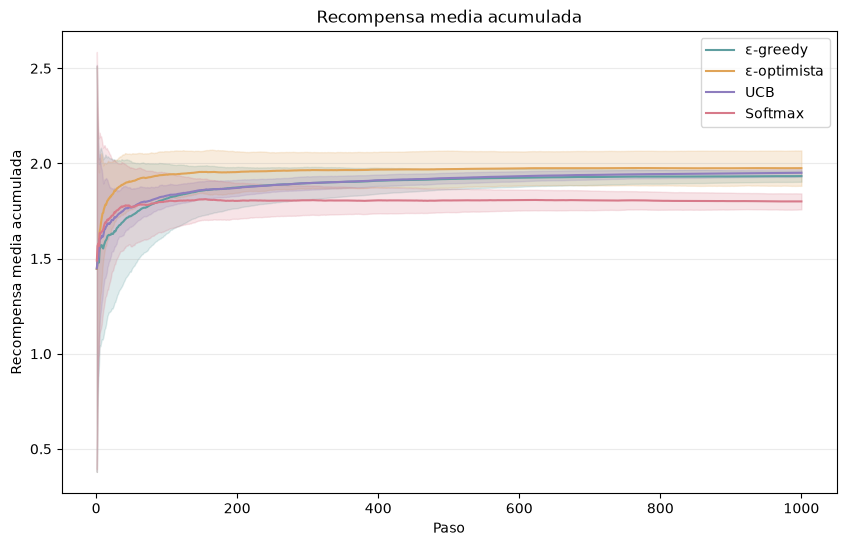

In [25]:
# ============================================================
# Recompensa media acumulada
# ============================================================

plt.figure(figsize=(10, 6))

for nombre, datos in analisis_base.items():

    media = datos["recompensa_media_acumulada_media"]
    std = datos["recompensa_media_acumulada_std"]

    x = np.arange(1, len(media) + 1)

    plt.plot(
        x,
        media,
        label=nombre,
        color=colores[nombre]
    )

    plt.fill_between(
        x,
        media - std,
        media + std,
        color=colores[nombre],
        alpha=0.20
    )

plt.xlabel("Paso")
plt.ylabel("Recompensa media acumulada")
plt.title("Recompensa media acumulada")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

### Gráfica selección acumulada del brazo óptimo

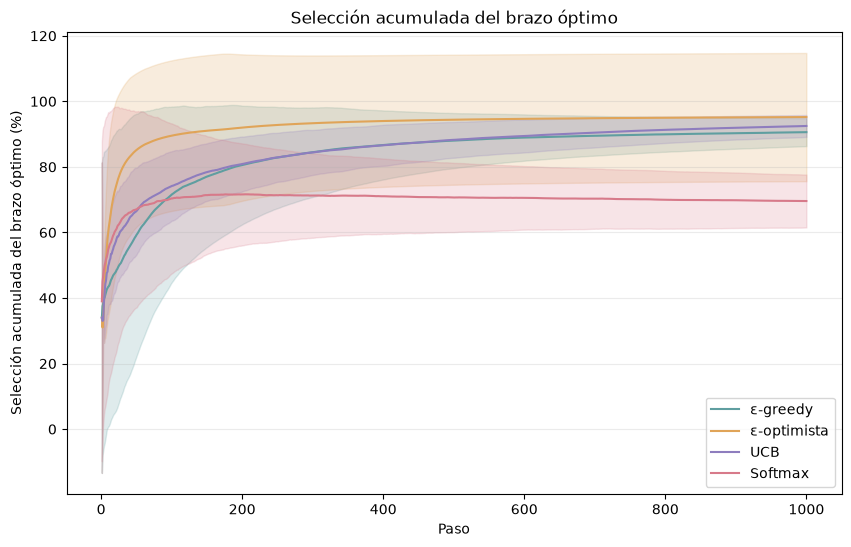

In [26]:
# ============================================================
# Selección acumulada del brazo óptimo
# ============================================================

plt.figure(figsize=(10, 6))

for nombre, datos in analisis_base.items():

    media = datos["seleccion_optima_media"]
    std = datos["seleccion_optima_std"]

    x = np.arange(1, len(media) + 1)

    plt.plot(
        x,
        media,
        label=nombre,
        color=colores[nombre]
    )

    plt.fill_between(
        x,
        media - std,
        media + std,
        color=colores[nombre],
        alpha=0.20
    )

plt.xlabel("Paso")
plt.ylabel("Selección acumulada del brazo óptimo (%)")
plt.title("Selección acumulada del brazo óptimo")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

### Gráfica Pseudo-regret acumulado

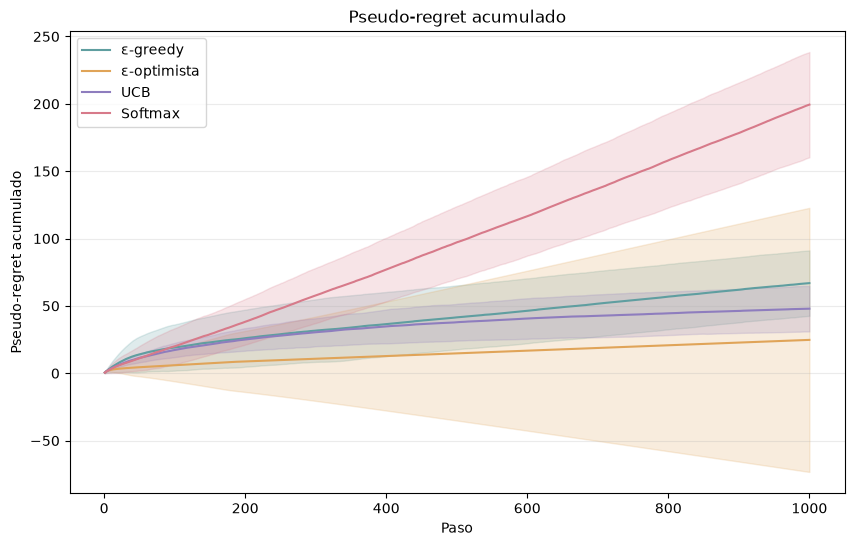

In [27]:
# ============================================================
# Pseudo-regret acumulado
# ============================================================

plt.figure(figsize=(10, 6))

for nombre, datos in analisis_base.items():

    media = datos["regret_media"]
    std = datos["regret_std"]

    x = np.arange(1, len(media) + 1)

    plt.plot(
        x,
        media,
        label=nombre,
        color=colores[nombre]
    )

    plt.fill_between(
        x,
        media - std,
        media + std,
        color=colores[nombre],
        alpha=0.20
    )

plt.xlabel("Paso")
plt.ylabel("Pseudo-regret acumulado")
plt.title("Pseudo-regret acumulado")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

### Gráfica Distribución de acciones

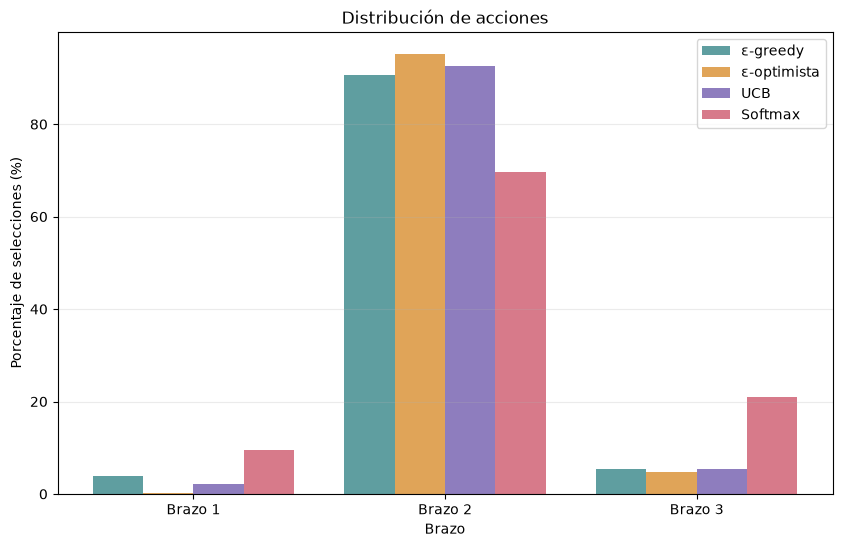

In [28]:
# ============================================================
# Distribución de acciones
# ============================================================

n_algoritmos = len(analisis_base)
n_brazos = len(MEANS)

x = np.arange(n_brazos)
ancho = 0.2

plt.figure(figsize=(10, 6))

for i, (nombre, datos) in enumerate(
    analisis_base.items()
):

    plt.bar(
        x + i * ancho,
        datos["distribucion_final"],
        width=ancho,
        label=nombre,
        color=colores[nombre]
    )

plt.xlabel("Brazo")
plt.ylabel("Porcentaje de selecciones (%)")
plt.title("Distribución de acciones")
plt.xticks(
    x + ancho * (n_algoritmos - 1) / 2,
    [f"Brazo {i + 1}" for i in range(n_brazos)]
)

plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

## 11. Sensibilidad de hiperparámetros

Compara los valores de ε, Q0, c y τ indicados en el enunciado.

In [29]:
# TODO: ejecutar el análisis de sensibilidad y presentar resultados.

# ============================================================
# 11. Sensibilidad de hiperparámetros
# ============================================================

sensibilidad = {
    "ε-greedy": {
        "parametro": "epsilon",
        "valores": [0.01, 0.10, 0.30],
    },

    "ε-optimista": {
        "parametro": "Q0",
        "valores": [2.0, 5.0, 10.0],
    },

    "UCB": {
        "parametro": "c",
        "valores": [0.5, 1.0, 2.0],
    },

    "Softmax": {
        "parametro": "tau",
        "valores": [0.05, 0.20, 1.0],
    },
}

In [30]:
# ============================================================
# Ejecutar análisis de sensibilidad
# ============================================================

resultados_sensibilidad = {}

for algoritmo, configuracion in sensibilidad.items():

    parametro = configuracion["parametro"]
    valores = configuracion["valores"]

    resultados_sensibilidad[algoritmo] = {}

    for valor in valores:

        runs = []

        for run in range(N_RUNS):

            seed = SEED + run

            # ----------------------------------------
            # ε-greedy
            # ----------------------------------------

            if algoritmo == "ε-greedy":

                resultado = run_epsilon_greedy(
                    epsilon=valor,
                    initial_value=0.0,
                    horizon=HORIZON,
                    seed=seed,
                )

            # ----------------------------------------
            # ε-optimista
            # ----------------------------------------

            elif algoritmo == "ε-optimista":

                resultado = run_epsilon_greedy(
                    epsilon=0.0,
                    initial_value=valor,
                    horizon=HORIZON,
                    seed=seed,
                )

            # ----------------------------------------
            # UCB
            # ----------------------------------------

            elif algoritmo == "UCB":

                resultado = run_ucb(
                    c=valor,
                    horizon=HORIZON,
                    seed=seed,
                )

            # ----------------------------------------
            # Softmax
            # ----------------------------------------

            elif algoritmo == "Softmax":

                resultado = run_softmax(
                    temperature=valor,
                    horizon=HORIZON,
                    seed=seed,
                )

            runs.append(resultado)

        resultados_sensibilidad[algoritmo][valor] = runs


print("Análisis de sensibilidad completado.")

Análisis de sensibilidad completado.


In [31]:
# ============================================================
# Tabla de sensibilidad con recompensa TOTAL
# ============================================================

filas = []

brazo_optimo = np.argmax(MEANS)

for algoritmo, resultados_algoritmo in resultados_sensibilidad.items():

    for valor, runs in resultados_algoritmo.items():

        recompensas = []
        acciones_optimas = []
        regrets = []

        conteos_brazos_totales = np.zeros(
            len(MEANS),
            dtype=int
        )

        for resultado in runs:

            rewards = resultado["reward"].to_numpy()

            actions = (
                resultado["action"].to_numpy() - 1
            )

            # --------------------------------------------
            # Recompensa de esta corrida
            # --------------------------------------------

            recompensa_corrida = np.sum(rewards)

            recompensas.append(recompensa_corrida)

            # --------------------------------------------
            # Acción óptima
            # --------------------------------------------

            acciones_optimas.append(
                np.mean(
                    actions == brazo_optimo
                ) * 100
            )

            # --------------------------------------------
            # Pseudo-regret
            # --------------------------------------------

            regrets.append(
                np.sum(
                    MEANS[brazo_optimo]
                    - MEANS[actions]
                )
            )

            # --------------------------------------------
            # Conteos totales de brazos
            # --------------------------------------------

            for brazo in range(len(MEANS)):

                conteos_brazos_totales[brazo] += np.sum(
                    actions == brazo
                )

        # --------------------------------------------
        # Crear fila
        # --------------------------------------------

        fila = {
            "Algoritmo": algoritmo,
            "Valor hiperparámetro": valor,

            # Promedio de las 100 corridas
            "Recompensa acumulada media":
                np.mean(recompensas),

            # TOTAL de las 100 corridas
            "Recompensa acumulada TOTAL":
                np.sum(recompensas),

            "Desv. estándar recompensa":
                np.std(recompensas),

            "A1 (total)":
                conteos_brazos_totales[0],

            "A2 (total)":
                conteos_brazos_totales[1],

            "A3 (total)":
                conteos_brazos_totales[2],

            "Acción óptima media (%)":
                np.mean(acciones_optimas),

            "Pseudo-regret medio":
                np.mean(regrets),

            "Desv. estándar regret":
                np.std(regrets),
        }

        filas.append(fila)


tabla_sensibilidad = pd.DataFrame(filas)


def resaltar_max(s):
    return [
        "background-color: #6FAF98; color: #174A3A; font-weight: bold"
        if v == s.max()
        else ""
        for v in s
    ]


tabla_estilizada = (
    tabla_sensibilidad.style
    .apply(
        resaltar_max,
        subset=["Recompensa acumulada TOTAL"]
    )
    .apply(
        resaltar_max,
        subset=["Acción óptima media (%)"]
    )
)

display(tabla_estilizada)

,Algoritmo,Valor hiperparámetro,Recompensa acumulada media,Recompensa acumulada TOTAL,Desv. estándar recompensa,A1 (total),A2 (total),A3 (total),Acción óptima media (%),Pseudo-regret medio,Desv. estándar regret
0,ε-greedy,0.010000,1846.503819,184650.381918,222.068845,10265,80004,9731,80.004000,151.305000,215.590931
1,ε-greedy,0.100000,1933.679470,193367.946952,29.966971,3977,90597,5426,90.597000,66.900000,24.308023
2,ε-greedy,0.300000,1842.794213,184279.421275,23.386286,10134,79197,10669,79.197000,154.685000,11.839057
3,ε-optimista,2.000000,1971.824440,197182.443957,102.578005,151,94419,5430,94.419000,28.660000,108.612658
4,ε-optimista,5.000000,1975.359033,197535.903308,93.212001,153,95199,4648,95.199000,24.770000,98.029216
5,ε-optimista,10.000000,1975.359033,197535.903308,93.212001,153,95199,4648,95.199000,24.770000,98.029216
6,UCB,0.500000,1993.689548,199368.954816,16.886051,228,99070,702,99.070000,5.790000,4.941245
7,UCB,1.000000,1983.549174,198354.917360,18.015613,675,97424,1901,97.424000,16.255000,11.271090
8,UCB,2.000000,1950.957228,195095.722838,20.334436,2070,92484,5446,92.484000,47.930000,16.895712
9,Softmax,0.050000,1569.187086,156918.708564,437.650848,31998,45986,22016,45.986000,430.060000,435.922609


Crearemos gráficas para tener mejor visualización de la sensibilidad

###  Sensibilidad de ε-greedy respecto a epsilon

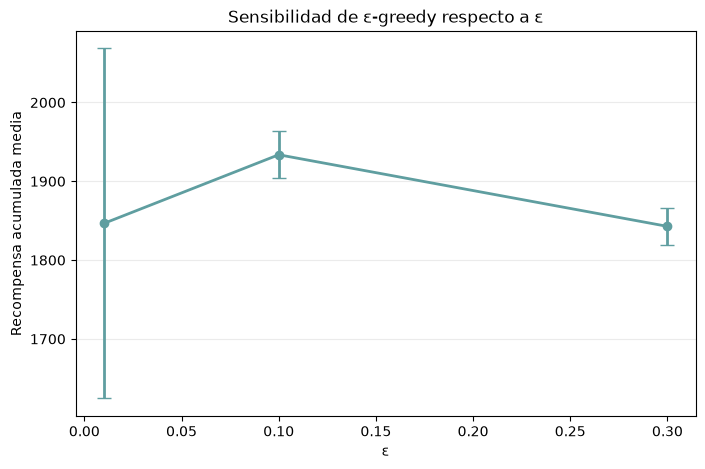

In [32]:
# ============================================================
# Sensibilidad de ε-greedy respecto a epsilon
# ============================================================

datos = tabla_sensibilidad[
    tabla_sensibilidad["Algoritmo"] == "ε-greedy"
]

plt.figure(figsize=(8, 5))

plt.errorbar(
    datos["Valor hiperparámetro"],
    datos["Recompensa acumulada media"],
    yerr=datos["Desv. estándar recompensa"],
    marker="o",
    linewidth=2,
    capsize=5,
    color=colores["ε-greedy"]
)

plt.xlabel("ε")
plt.ylabel("Recompensa acumulada media")
plt.title("Sensibilidad de ε-greedy respecto a ε")
plt.grid(axis="y", alpha=0.25)

plt.show()

### ε-optimista — sensibilidad a Q

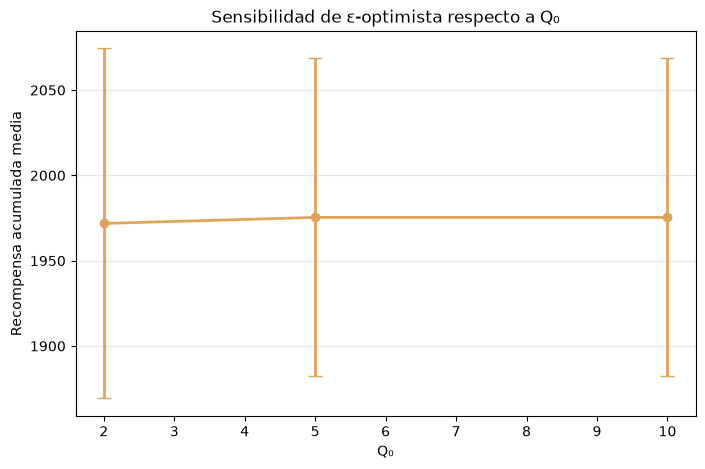

In [33]:
# ============================================================
# Sensibilidad de ε-optimista respecto a Q0
# ============================================================

datos = tabla_sensibilidad[
    tabla_sensibilidad["Algoritmo"] == "ε-optimista"
]

plt.figure(figsize=(8, 5))

plt.errorbar(
    datos["Valor hiperparámetro"],
    datos["Recompensa acumulada media"],
    yerr=datos["Desv. estándar recompensa"],
    marker="o",
    linewidth=2,
    capsize=5,
    color=colores["ε-optimista"]
)

plt.xlabel("Q₀")
plt.ylabel("Recompensa acumulada media")
plt.title("Sensibilidad de ε-optimista respecto a Q₀")
plt.grid(axis="y", alpha=0.3)

plt.show()

### UCB — sensibilidad a c

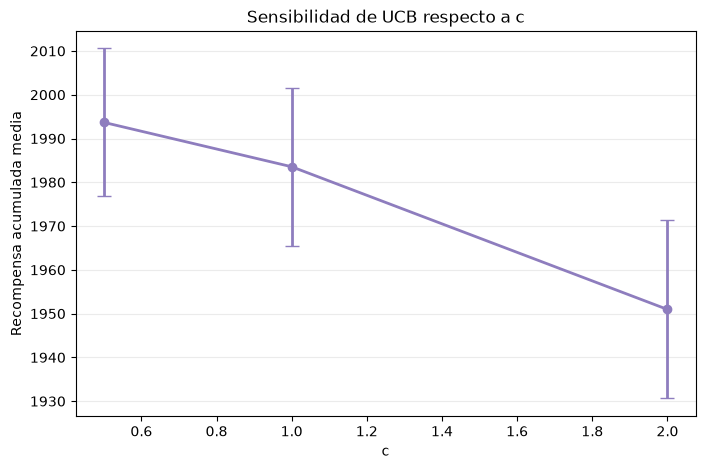

In [34]:
# ============================================================
# Sensibilidad de UCB respecto a c
# ============================================================

datos = tabla_sensibilidad[
    tabla_sensibilidad["Algoritmo"] == "UCB"
]

plt.figure(figsize=(8, 5))

plt.errorbar(
    datos["Valor hiperparámetro"],
    datos["Recompensa acumulada media"],
    yerr=datos["Desv. estándar recompensa"],
    marker="o",
    linewidth=2,
    capsize=5,
    color=colores["UCB"]
)

plt.xlabel("c")
plt.ylabel("Recompensa acumulada media")
plt.title("Sensibilidad de UCB respecto a c")
plt.grid(axis="y", alpha=0.25)

plt.show()

### Softmax — sensibilidad a τ

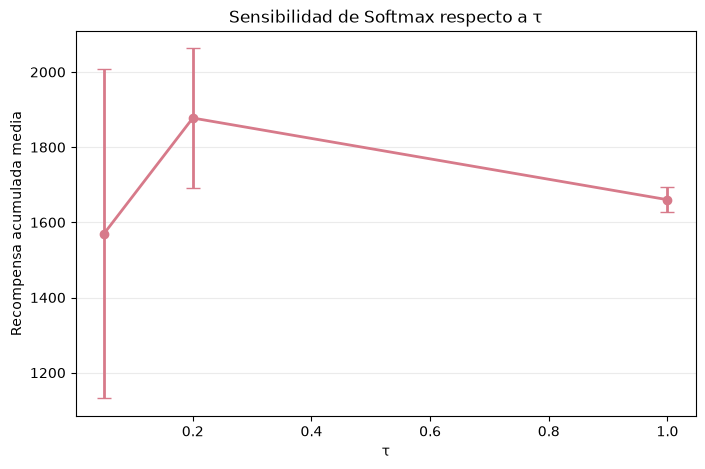

In [35]:
# ============================================================
# Sensibilidad de Softmax respecto a tau
# ============================================================

datos = tabla_sensibilidad[
    tabla_sensibilidad["Algoritmo"] == "Softmax"
]

plt.figure(figsize=(8, 5))

plt.errorbar(
    datos["Valor hiperparámetro"],
    datos["Recompensa acumulada media"],
    yerr=datos["Desv. estándar recompensa"],
    marker="o",
    linewidth=2,
    capsize=5,
    color=colores["Softmax"]
)

plt.xlabel("τ")
plt.ylabel("Recompensa acumulada media")
plt.title("Sensibilidad de Softmax respecto a τ")
plt.grid(axis="y", alpha=0.25)

plt.show()

## 12. Interpretación

Responde las nueve preguntas del enunciado con evidencia de tus resultados.

1. ¿Qué algoritmo obtuvo mayor recompensa acumulada?
2. ¿Cuál identificó más rápido el brazo óptimo?
3. ¿Cuál obtuvo menor regret final?
4. ¿Qué comportamiento produjo el inicio optimista?
5. ¿Cómo cambia UCB al modificar `c`?
6. ¿Cómo cambia Softmax al modificar la temperatura?
7. ¿Cuál estrategia fue más sensible a la alta varianza de `A3`?
8. ¿Existe un algoritmo ganador para todas las métricas y horizontes?
9. ¿Qué método recomendarías y bajo qué condiciones?

In [36]:
display(tabla_resumen)

,Algoritmo,Recompensa acumulada media,Desv. estándar recompensa,Recompensa media acumulada,Acción óptima (%),Desv. estándar acción óptima,Pseudo-regret acumulado,Desv. estándar regret
0,ε-greedy,1933.679470,29.966971,1.933679,90.597,4.264937,66.90,24.308023
1,ε-optimista,1975.359033,93.212001,1.975359,95.199,19.566407,24.77,98.029216
2,UCB,1950.957228,20.334436,1.950957,92.484,3.340740,47.93,16.895712
3,Softmax,1800.582825,42.002428,1.800583,69.584,8.069309,199.41,39.108208


#### 1. ¿Qué algoritmo obtuvo mayor recompensa acumulada?

In [37]:
fila_max = tabla_resumen.loc[
    tabla_resumen["Recompensa acumulada media"].idxmax()
]

display(fila_max[["Algoritmo", "Recompensa acumulada media"]])

Algoritmo                     ε-optimista
Recompensa acumulada media    1975.359033
Name: 1, dtype: object

#### 2. ¿Cuál identificó más rápido el brazo óptimo?

In [38]:
# ============================================================
# Velocidad de identificación del brazo óptimo
# Criterio: alcanzar 90% de selección acumulada
# ============================================================

umbral = 90

for nombre, datos in analisis_base.items():

    seleccion = datos["seleccion_optima_media"]

    pasos = np.where(seleccion >= umbral)[0]

    if len(pasos) > 0:
        primer_paso = pasos[0] + 1
        print(
            f"{nombre}: paso {primer_paso}"
        )
    else:
        print(
            f"{nombre}: no alcanza {umbral}%"
        )

ε-greedy: paso 820
ε-optimista: paso 112
UCB: paso 655
Softmax: no alcanza 90%


El algoritmo que identifica más rápido el brazo óptimo es ε-optimista, alcanzando un 90% de la seleccióna cumulada en el paso 112.

#### 3. ¿Cuál obtuvo menor regret final?

In [39]:
fila_max = tabla_resumen.loc[
    tabla_resumen["Pseudo-regret acumulado"].idxmin()
]

display(fila_max[["Algoritmo", "Pseudo-regret acumulado"]])

Algoritmo                  ε-optimista
Pseudo-regret acumulado          24.77
Name: 1, dtype: object

ε-optimista tuvo el menor regret, por lo que dejó de obtener menos recompensa potencial que los otros algoritmos, por lo cual pasó menos tiempo tomando decisiones no óptimas.

#### 4. ¿Qué comportamiento produjo el inicio optimista?

In [40]:
display(resultados_optimista[0].head(20))

,step,action,reward,q_a1,q_a2,q_a3
0,0,1,0.603439,0.603439,5.000000,5.000000
1,1,3,1.860857,0.603439,5.000000,1.860857
2,2,2,1.051837,0.603439,1.051837,1.860857
3,3,3,3.593658,0.603439,1.051837,2.727257
4,4,3,2.457442,0.603439,1.051837,2.637319
5,5,3,1.061929,0.603439,1.051837,2.243471
6,6,3,1.032076,0.603439,1.051837,2.001192
7,7,3,1.955753,0.603439,1.051837,1.993619
8,8,3,1.098510,0.603439,1.051837,1.865746
9,9,3,1.161137,0.603439,1.051837,1.777670


Al inicio optimista obligó al agente a explorar inicialmente todas las opciones, porque todas comenzaron con valores Q=5, mayores que las recompensas que realmente podían obtener. Al elegir una acción por primera vez, su valor Q se actualizaba con la recompensa obtenida, mientras que las acciones que todavía no habían sido exploradas seguían teniendo un valor Q mayor. Por eso, el agente se veía incentivado a probar las acciones restantes hasta obtener información sobre ellas.

Sin embargo, en la primera corrida, por ejemplo, tuvo la mala suerte de que cuando exploró el brazo 2 obtuvo una recompensa relativamente baja, de 1.05. En ese momento, el brazo 3 tenía una estimación Q=1.86, por lo que el algoritmo continuó seleccionando el brazo 3, aunque su recompensa media real era menor que la del brazo 2. Esto muestra cómo una primera recompensa desfavorable puede hacer que una acción buena parezca peor de lo que realmente es.

In [41]:
display(tabla_sensibilidad)

,Algoritmo,Valor hiperparámetro,Recompensa acumulada media,Recompensa acumulada TOTAL,Desv. estándar recompensa,A1 (total),A2 (total),A3 (total),Acción óptima media (%),Pseudo-regret medio,Desv. estándar regret
0,ε-greedy,0.01,1846.503819,184650.381918,222.068845,10265,80004,9731,80.004,151.305,215.590931
1,ε-greedy,0.10,1933.679470,193367.946952,29.966971,3977,90597,5426,90.597,66.900,24.308023
2,ε-greedy,0.30,1842.794213,184279.421275,23.386286,10134,79197,10669,79.197,154.685,11.839057
3,ε-optimista,2.00,1971.824440,197182.443957,102.578005,151,94419,5430,94.419,28.660,108.612658
4,ε-optimista,5.00,1975.359033,197535.903308,93.212001,153,95199,4648,95.199,24.770,98.029216
5,ε-optimista,10.00,1975.359033,197535.903308,93.212001,153,95199,4648,95.199,24.770,98.029216
6,UCB,0.50,1993.689548,199368.954816,16.886051,228,99070,702,99.070,5.790,4.941245
7,UCB,1.00,1983.549174,198354.917360,18.015613,675,97424,1901,97.424,16.255,11.271090
8,UCB,2.00,1950.957228,195095.722838,20.334436,2070,92484,5446,92.484,47.930,16.895712
9,Softmax,0.05,1569.187086,156918.708564,437.650848,31998,45986,22016,45.986,430.060,435.922609


#### 5. ¿Cómo cambia UCB al modificar `c`?

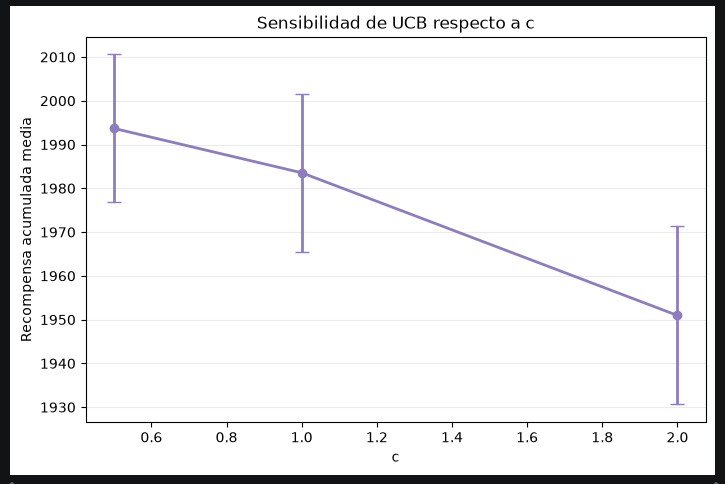

In [42]:
tabla_sensibilidad[['Algoritmo','Valor hiperparámetro','Recompensa acumulada media','Acción óptima media (%)','Pseudo-regret medio']][tabla_sensibilidad['Algoritmo'] == 'UCB']

,Algoritmo,Valor hiperparámetro,Recompensa acumulada media,Acción óptima media (%),Pseudo-regret medio
6,UCB,0.5,1993.689548,99.070,5.790
7,UCB,1.0,1983.549174,97.424,16.255
8,UCB,2.0,1950.957228,92.484,47.930


Si aumentamos mucho la exploración, aumentando c, el algoritmo tarda más tiempo en concentrarse en una acción óptima, porque el peso que tiene el término de exploración es mayor. Por lo tanto, UCB da más importancia a las acciones que han sido exploradas pocas veces y puede seguir probándolas durante más tiempo antes de concentrarse en la acción óptima. En nuestros resultados, al aumentar c de 0.5 a 2, la recompensa acumulada disminuyó de 1993.69 a 1950.96 y el regret aumentó de 5.79 a 47.93.

#### 6. ¿Cómo cambia Softmax al modificar la temperatura?

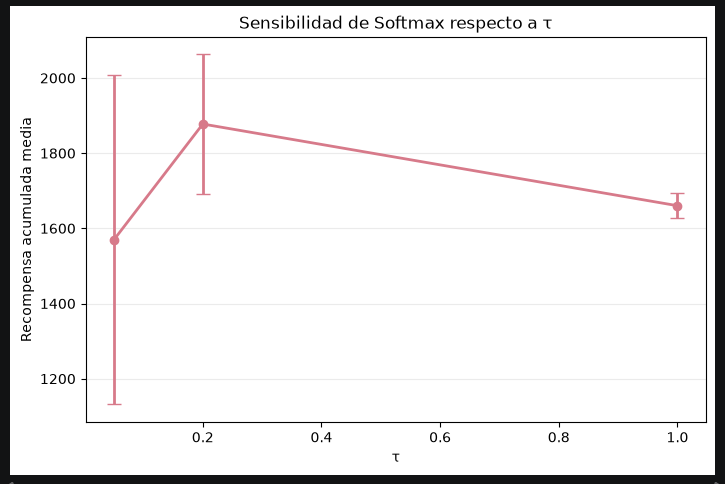

In [43]:
tabla_sensibilidad[['Algoritmo','Valor hiperparámetro','Recompensa acumulada media','Acción óptima media (%)','Pseudo-regret medio']][tabla_sensibilidad['Algoritmo'] == 'Softmax']

,Algoritmo,Valor hiperparámetro,Recompensa acumulada media,Acción óptima media (%),Pseudo-regret medio
9,Softmax,0.05,1569.187086,45.986,430.060
10,Softmax,0.20,1877.582317,78.131,124.015
11,Softmax,1.00,1660.276255,51.091,338.980


Cuando la temperatura es muy grande, las diferencias entre las recompensas estimadas de cada acción importan menos, por lo que las probabilidades de elegir las distintas acciones se vuelven más parecidas. El algoritmo explora más y, por lo tanto, puede demorarse más en concentrarse en una acción.

Cuando τ es menor, las diferencias entre las recompensas estimadas importan más, por lo que el algoritmo selecciona con mayor probabilidad la acción con mayor estimación de recompensa. Esto hace que explote más, pero no significa necesariamente que encuentre la acción óptima más rápido, porque puede concentrarse prematuramente en una acción que inicialmente parece buena.

#### 7. ¿Cuál estrategia fue más sensible a la alta varianza de `A3`?

In [44]:
tabla_sensibilidad[['Algoritmo','Valor hiperparámetro','Recompensa acumulada media','A1 (total)','A2 (total)','A3 (total)']]

,Algoritmo,Valor hiperparámetro,Recompensa acumulada media,A1 (total),A2 (total),A3 (total)
0,ε-greedy,0.01,1846.503819,10265,80004,9731
1,ε-greedy,0.10,1933.679470,3977,90597,5426
2,ε-greedy,0.30,1842.794213,10134,79197,10669
3,ε-optimista,2.00,1971.824440,151,94419,5430
4,ε-optimista,5.00,1975.359033,153,95199,4648
5,ε-optimista,10.00,1975.359033,153,95199,4648
6,UCB,0.50,1993.689548,228,99070,702
7,UCB,1.00,1983.549174,675,97424,1901
8,UCB,2.00,1950.957228,2070,92484,5446
9,Softmax,0.05,1569.187086,31998,45986,22016


Softmax mostró el comportamiento más sensible frente a A3. En particular, con τ=1.0, A3 fue seleccionado 30 022 veces de 100 000, mientras que UCB con c=0.5, por ejemplo, solo lo seleccionó 702 veces. Esta elevada selección de A3 coincidió con una menor recompensa acumulada y un mayor regret. Por lo tanto, Softmax fue el método que mostró mayor influencia de A3 en este experimento.

Esto puede explicarse con la respuesta de la pregunta anterior. Softmax compara los valores estimados de las acciones y τ moldea el comportamiento entre exploración y explotación. En este caso, con τ=1, el agente mantuvo un comportamiento bastante exploratorio y no pudo concentrarse eficientemente en el brazo óptimo durante el horizonte estudiado.

La alta varianza de A3 puede hacer que sus recompensas observadas sean muy diferentes de su media real. Esto puede producir estimaciones Q temporalmente engañosas. Softmax utiliza directamente estas estimaciones para determinar las probabilidades de selección, por lo que puede verse influenciado por esas fluctuaciones y continuar seleccionando A3 aunque su recompensa esperada sea inferior a la de A2.

#### 8. ¿Existe un algoritmo ganador para todas las métricas y horizontes?

In [45]:
display(tabla_estilizada)

,Algoritmo,Valor hiperparámetro,Recompensa acumulada media,Recompensa acumulada TOTAL,Desv. estándar recompensa,A1 (total),A2 (total),A3 (total),Acción óptima media (%),Pseudo-regret medio,Desv. estándar regret
0,ε-greedy,0.010000,1846.503819,184650.381918,222.068845,10265,80004,9731,80.004000,151.305000,215.590931
1,ε-greedy,0.100000,1933.679470,193367.946952,29.966971,3977,90597,5426,90.597000,66.900000,24.308023
2,ε-greedy,0.300000,1842.794213,184279.421275,23.386286,10134,79197,10669,79.197000,154.685000,11.839057
3,ε-optimista,2.000000,1971.824440,197182.443957,102.578005,151,94419,5430,94.419000,28.660000,108.612658
4,ε-optimista,5.000000,1975.359033,197535.903308,93.212001,153,95199,4648,95.199000,24.770000,98.029216
5,ε-optimista,10.000000,1975.359033,197535.903308,93.212001,153,95199,4648,95.199000,24.770000,98.029216
6,UCB,0.500000,1993.689548,199368.954816,16.886051,228,99070,702,99.070000,5.790000,4.941245
7,UCB,1.000000,1983.549174,198354.917360,18.015613,675,97424,1901,97.424000,16.255000,11.271090
8,UCB,2.000000,1950.957228,195095.722838,20.334436,2070,92484,5446,92.484000,47.930000,16.895712
9,Softmax,0.050000,1569.187086,156918.708564,437.650848,31998,45986,22016,45.986000,430.060000,435.922609


No existe un algoritmo ganador para todas las métricas y horizontes. En nuestro experimento, UCB con c=0.5 mostró el mejor desempeño en términos de recompensa acumulada, selección final del brazo óptimo y pseudo-regret, mientras que ε-optimista identificó el brazo óptimo más rápidamente. Además, los resultados cambiaron al modificar los hiperparámetros de cada algoritmo, por lo que el mejor método depende del escenario, las métricas que se quieran optimizar y el horizonte de decisión.

#### 9. ¿Qué método recomendarías y bajo qué condiciones?

De acuerdo con la tabla de sensibilidad y comparando las distintas corridas con diferentes configuraciones de cada algoritmo, diría que UCB tuvo el mejor desempeño general, seguido por ε-optimista. Es posible que en algunas corridas con diferentes semillas no haya obtenido el mejor resultado, pero en la vista general fue el método que obtuvo una de las mayores recompensas acumuladas medias, una baja desviación estándar de la recompensa y, con c=0.5, el menor pseudo-regret y la mayor selección del brazo óptimo. Sin embargo, todo depende del escenario que tengamos y de los hiperparámetros utilizados. Para esta prueba, UCB mostró ser una estrategia particularmente adecuada cuando buscamos un buen equilibrio entre exploración y explotación y un bajo regret, mientras que ε-optimista fue especialmente bueno para identificar rápidamente el brazo óptimo.

## 13. Uso de inteligencia artificial

Documenta herramientas, preguntas, sugerencias, ajustes manuales y validación.

### Uso de ChatGPT

Durante el desarrollo de este reto se utilizó ChatGPT como herramienta de apoyo para la comprensión, implementación y revisión del código.

La herramienta se utilizó principalmente para:

Comprender los conceptos de exploración y explotación y el funcionamiento de los algoritmos ε-greedy, inicio optimista, UCB y Softmax.
Resolver dudas puntuales sobre las fórmulas y el comportamiento de los algoritmos.
Recibir orientación para implementar las funciones en Python.
Revisar y depurar errores encontrados durante la ejecución del notebook.
Analizar resultados experimentales y ayudar a identificar comportamientos inesperados.
Mejorar la presentación de tablas y gráficas.

Las decisiones sobre los experimentos, la ejecución del código y la interpretación final de los resultados fueron realizadas y verificadas durante el desarrollo del notebook. Las conclusiones del reto fueron elaboradas a partir de los resultados obtenidos experimentalmente.

El uso de la herramienta fue principalmente como tutor y asistente de programación, no como sustituto del análisis realizado durante el reto.

## 14. Conclusiones

Incluye entre cuatro y seis conclusiones sustentadas en el experimento.

1. Los diferentes métodos de exploración y explotación tienen comportamientos bastante diferentes, y no existe uno que sea siempre mejor que los demás. El desempeño depende mucho del escenario, de los hiperparámetros que se utilicen y de lo que queramos optimizar. En este experimento, por ejemplo, UCB mostró el mejor desempeño general, mientras que ε-optimista fue especialmente bueno para identificar rápidamente el brazo óptimo.

2. El inicio optimista permitió explorar las acciones sin necesidad de utilizar exploración aleatoria. Al comenzar todas las acciones con un valor Q alto, las acciones que todavía no habían sido exploradas mantenían una estimación mayor que las que ya habían recibido una recompensa. Sin embargo, también vimos que una primera recompensa poco representativa puede afectar bastante la estimación de una acción y hacer que el agente se concentre en otra que inicialmente parece mejor.

3. UCB mostró que aumentar demasiado la exploración no necesariamente mejora el resultado. Al aumentar c, el algoritmo da más importancia al término de exploración y tarda más en concentrarse en el brazo óptimo. En nuestros resultados, c=0.5 obtuvo mejores resultados que c=1 y c=2, tanto en recompensa acumulada como en regret.

4. Softmax fue bastante sensible a la temperatura y al comportamiento variable de A3. Cuando la temperatura aumentó, las diferencias entre las estimaciones de las acciones tuvieron menos peso y el algoritmo exploró más. Esto hizo que siguiera seleccionando A3 muchas veces, a pesar de que su recompensa esperada era menor que la de A2. La alta varianza de A3 podía hacer que sus recompensas observadas fueran muy diferentes de su media y, por lo tanto, afectar temporalmente su estimación Q.

5. Los experimentos mostraron que no basta con mirar una sola métrica para decidir qué algoritmo es mejor. La recompensa acumulada, el regret, la velocidad para identificar el brazo óptimo y la distribución de acciones pueden llevar a conclusiones diferentes. Por eso considero que la elección del algoritmo debe hacerse dependiendo del escenario y de qué aspecto del problema sea más importante. En este experimento, UCB con c=0.5 tuvo el mejor desempeño general, pero ε-optimista fue el que encontró más rápidamente el brazo óptimo.